# 🇻🇳 VNINDEX Market Regime Detection — HDBSCAN

Detects market regimes from VNINDEX history using HDBSCAN clustering on 4 feature groups:
1. **VN-Index** — vol, trend, drawdown, skew, vol-of-vol (8 features)
2. **Market Breadth** — advance/decline, % above SMA, breadth momentum (5 features)
3. **Correlation Regime** — avg mkt correlation, dispersion, absorption ratio (3 features)
4. **Volume Regime** — total vol z-score, up-vol ratio, vol trend (4 features)

PCA reduces to 8 components before HDBSCAN (curse-of-dimensionality guard).

**Outputs**
| File | Contents |
|------|----------|
| `regime_labels_vnindex_<ts>.h5` | date-indexed regime labels (walk-forward + static) |
| `regime_clusterer_vnindex_<ts>.joblib` | fitted pipeline (scaler + PCA + HDBSCAN) |
| `regime_stats_vnindex_<ts>.csv` | centroid stats + auto-labels per cluster |

**Reference**: `notebooks/regime_detection_HBDSCAN.md`

In [170]:
import os
import warnings
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import f_oneway

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

ARTIFACTS_DIR = Path('../models')
ARTIFACTS_DIR.mkdir(exist_ok=True)
TS = datetime.now().strftime('%Y%m%d')

PCA_N_COMPONENTS = 8   # reduce before HDBSCAN — guards against curse of dimensionality

print(f'Artifacts → {ARTIFACTS_DIR.resolve()}')
print(f'Timestamp : {TS}')

Artifacts → /Users/phuchuynh/Work/all-in-one-portfolio/models
Timestamp : 20260502


# 1. Load Data

Load VNINDEX and the full cross-sectional stocks universe (needed for breadth, correlation, and volume features).

VNINDEX        : 2,500 trading days  (2016-04-20 → 2026-04-17)
Stocks universe: 196 symbols
Price range    : 568.0 → 1902.9


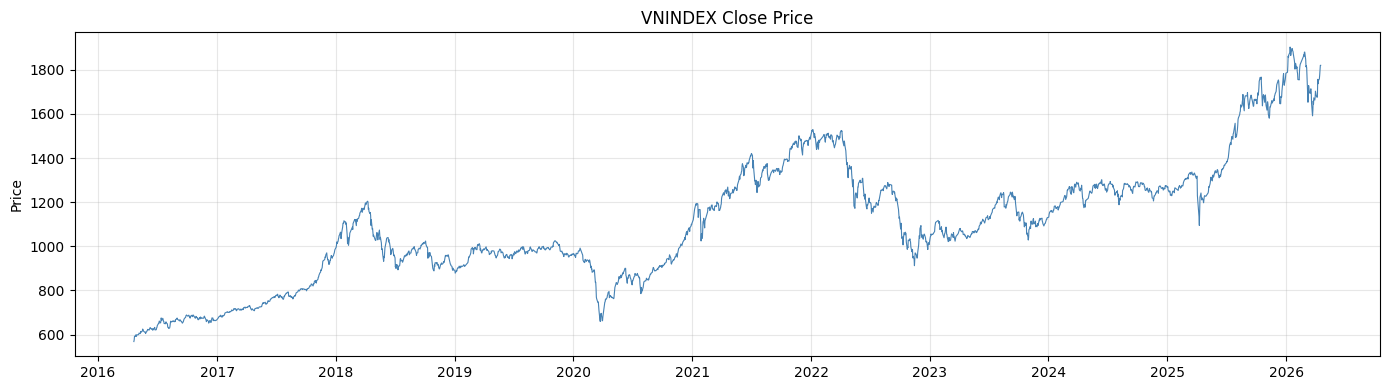

In [171]:
local_file = 'stocks_data_latest.h5'

with pd.HDFStore(local_file, mode='r') as store:
    stocks = store['stocks']

stocks.index = pd.to_datetime(stocks.index)

# VNINDEX series
vnindex = stocks['close']['VNINDEX'].dropna().sort_index()

# Cross-section: all stocks except VNINDEX
# stocks['close'].columns is single-level (197 symbols) — use this for the mask,
# NOT stocks.columns.get_level_values('symbol') which returns 985 (5 fields × 197 symbols)
_syms = stocks['close'].columns
_mask = _syms != 'VNINDEX'
close_df  = stocks['close'].loc[:, _mask].sort_index()
volume_df = stocks['volume'].loc[:, _mask].sort_index()

# Align to common trading-day index
common_idx = vnindex.index.intersection(close_df.index)
vnindex    = vnindex.reindex(common_idx)
close_df   = close_df.reindex(common_idx)
volume_df  = volume_df.reindex(common_idx)

N_STOCKS = close_df.shape[1]
N_DAYS   = len(common_idx)

print(f'VNINDEX        : {N_DAYS:,} trading days  ({vnindex.index.min().date()} → {vnindex.index.max().date()})')
print(f'Stocks universe: {N_STOCKS} symbols')
print(f'Price range    : {vnindex.min():.1f} → {vnindex.max():.1f}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(vnindex.index, vnindex.values, linewidth=0.8, color='steelblue')
ax.set_title('VNINDEX Close Price')
ax.set_ylabel('Price')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Feature Engineering

All features are **stationary** and **look-ahead-free**.

## 2.1 VN-Index Features (8)
| Feature | Captures |
|---------|----------|
| `vnindex_vol_20` | Realised vol 20d |
| `vnindex_vol_pct` | Vol percentile in 252d history |
| `vnindex_trend_60` | 60d return — trend direction |
| `vnindex_drawdown` | Drawdown from 252d high |
| `vnindex_above_sma200` | Distance from 200d SMA |
| `downside_vol_60` | Downside-only vol — crash asymmetry |
| `vn_skew_60` | Return skewness |
| `vol_of_vol_20` | Vol-of-vol — regime instability |

## 2.2 Market Breadth (5)
| Feature | Captures |
|---------|----------|
| `advances_ratio` | % stocks with positive return today |
| `pct_above_sma20` | % stocks above their 20d SMA |
| `pct_above_sma200` | % stocks above their 200d SMA — bull/bear breadth |
| `breadth_momentum` | 20d change in pct_above_sma20 — breadth trend |
| `adv_vol_ratio` | Advancing volume / total volume (Arms-index numerator) |

## 2.3 Correlation Regime (3)
| Feature | Captures |
|---------|----------|
| `avg_mkt_corr_60` | Avg 60d rolling correlation of stocks to VNINDEX — market integration |
| `corr_dispersion_60` | Std of per-stock correlations — idiosyncratic vs systematic |
| `absorption_ratio` | Variance explained by PC1 of 60d returns — systemic risk |

## 2.4 Volume Regime (4)
| Feature | Captures |
|---------|----------|
| `total_vol_zscore` | Market total volume z-score (252d) |
| `up_vol_ratio` | Volume on advancing stocks / total — institutional participation |
| `vol_trend_20` | 20d log-trend in market volume |
| `dollar_vol_zscore` | Total dollar volume z-score (252d) |

In [172]:
def compute_vn_index_features(vnindex: pd.Series) -> pd.DataFrame:
    """8 VNINDEX-only stationary features."""
    vn_ret = vnindex.pct_change()
    f = pd.DataFrame(index=vnindex.index)

    vol_20 = vn_ret.rolling(20).std() * np.sqrt(252)
    f['vnindex_vol_20']      = vol_20
    f['vnindex_vol_pct']     = vol_20.rolling(252).rank(pct=True)
    f['vnindex_trend_60']    = vnindex.pct_change(60)
    f['vnindex_drawdown']    = vnindex / vnindex.rolling(252).max() - 1
    f['vnindex_above_sma200'] = vnindex / vnindex.rolling(200).mean() - 1
    neg_ret = vn_ret.where(vn_ret < 0)
    f['downside_vol_60']    = neg_ret.rolling(60, min_periods=10).std() * np.sqrt(252)
    f['vn_skew_60']         = vn_ret.rolling(60).skew()
    f['vol_of_vol_20']      = vol_20.rolling(20).std()

    return f


features_vn = compute_vn_index_features(vnindex)
print(f'VN-index features: {features_vn.shape[1]}  |  NaN rows: {features_vn.isna().any(axis=1).sum()}')

VN-index features: 8  |  NaN rows: 271


## 2.2 Market Breadth Features

In [173]:
def compute_market_breadth_features(close_df: pd.DataFrame,
                                     volume_df: pd.DataFrame) -> pd.DataFrame:
    """
    5 cross-sectional breadth features.
    All values are daily snapshots — no look-ahead.
    """
    daily_ret = close_df.pct_change()
    f = pd.DataFrame(index=close_df.index)

    # 1. Advances ratio — fraction of stocks with positive return
    f['advances_ratio'] = (daily_ret > 0).sum(axis=1) / close_df.notna().sum(axis=1)

    # 2-3. % above 20d / 200d SMA
    sma20  = close_df.rolling(20,  min_periods=15).mean()
    sma200 = close_df.rolling(200, min_periods=150).mean()
    valid  = close_df.notna().sum(axis=1).clip(lower=1)
    f['pct_above_sma20']  = (close_df > sma20).sum(axis=1)  / valid
    f['pct_above_sma200'] = (close_df > sma200).sum(axis=1) / valid

    # 4. Breadth momentum — 20d change in pct_above_sma20
    f['breadth_momentum'] = f['pct_above_sma20'].diff(20)

    # 5. Advancing volume ratio — volume on up-stocks / total volume
    up_mask   = (daily_ret > 0).astype(float)
    up_vol    = (volume_df * up_mask).sum(axis=1)
    total_vol = volume_df.sum(axis=1).replace(0, np.nan)
    f['adv_vol_ratio'] = up_vol / total_vol

    return f


features_breadth = compute_market_breadth_features(close_df, volume_df)
print(f'Breadth features : {features_breadth.shape[1]}  |  NaN rows: {features_breadth.isna().any(axis=1).sum()}')
print(features_breadth.describe().round(4))

Breadth features : 5  |  NaN rows: 20
       advances_ratio  pct_above_sma20  pct_above_sma200  breadth_momentum  \
count       2500.0000        2500.0000         2500.0000         2480.0000   
mean           0.3959           0.4703            0.4886            0.0033   
std            0.1964           0.2364            0.2615            0.3194   
min            0.0000           0.0000            0.0000           -0.7959   
25%            0.2551           0.2908            0.2959           -0.1939   
50%            0.3673           0.4490            0.4796           -0.0102   
75%            0.5153           0.6582            0.7041            0.1888   
max            0.9847           0.9796            0.9592            0.8929   

       adv_vol_ratio  
count      2500.0000  
mean          0.4319  
std           0.2704  
min           0.0000  
25%           0.2019  
50%           0.3987  
75%           0.6592  
max           0.9987  


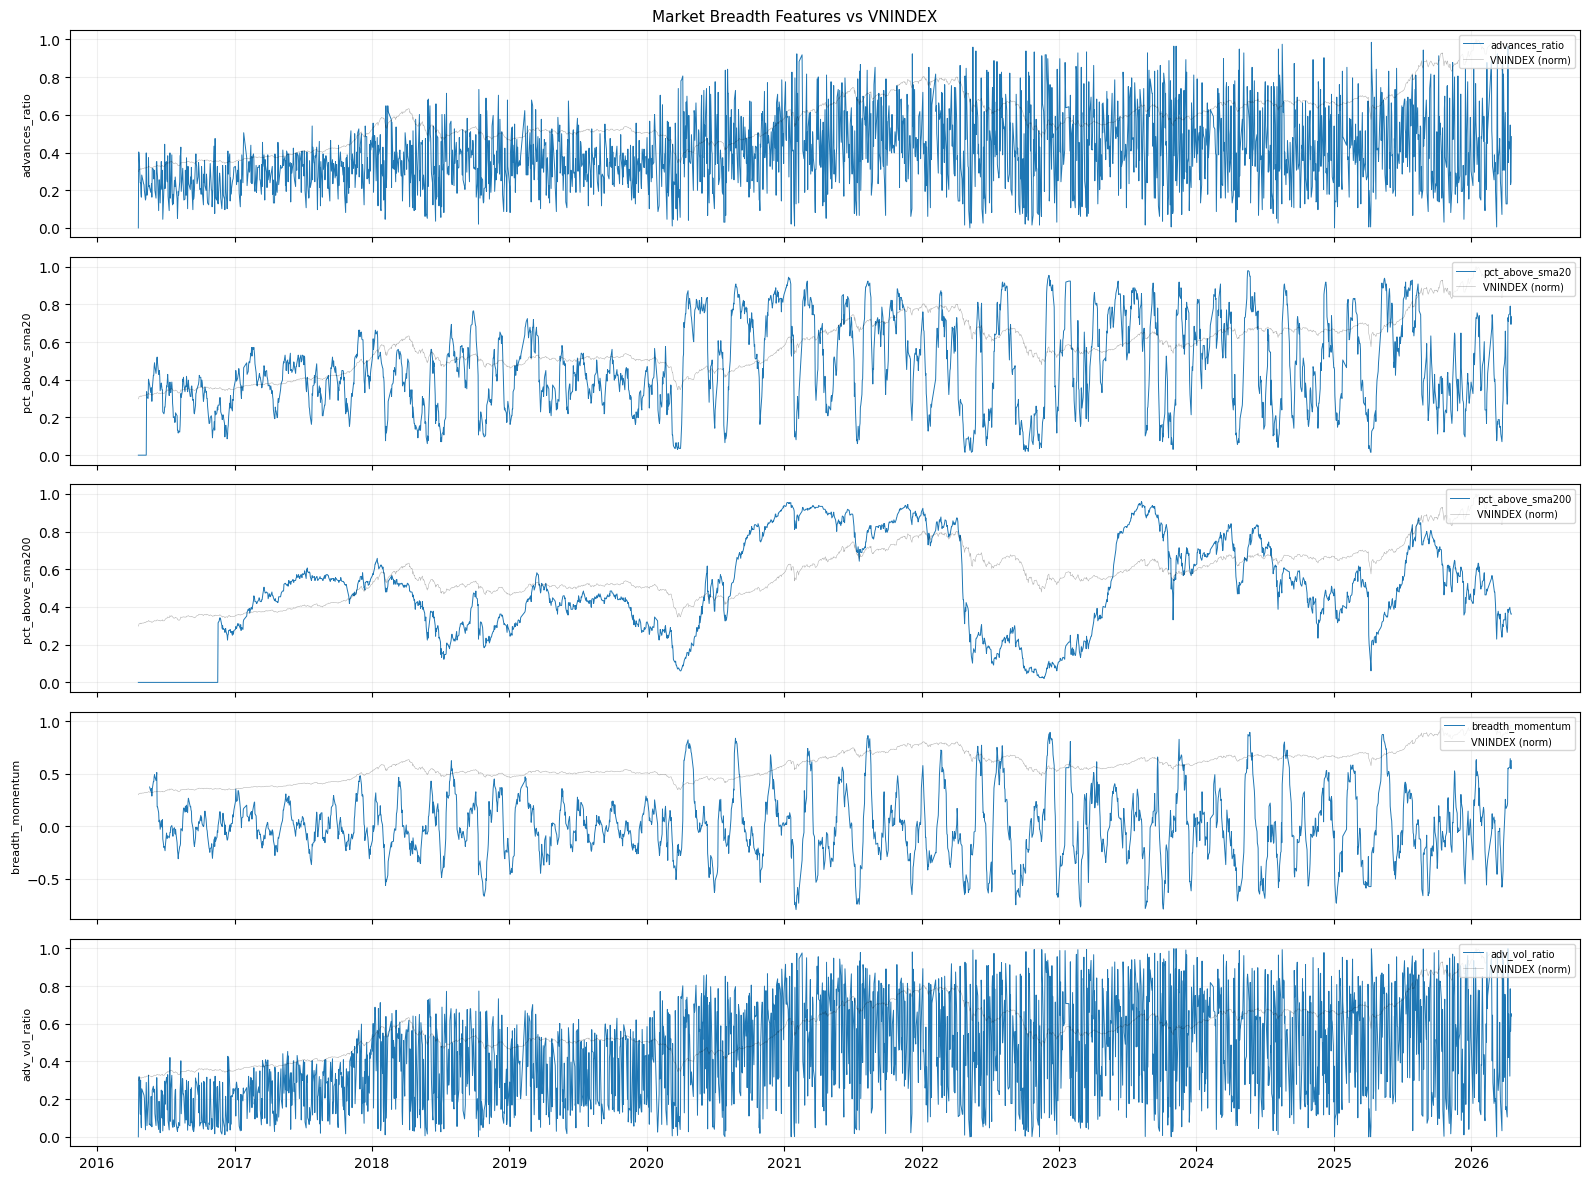

In [174]:
fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)
vn_norm = vnindex / vnindex.max()

for ax, col in zip(axes, features_breadth.columns):
    ax.plot(features_breadth.index, features_breadth[col], linewidth=0.7, label=col)
    ax.plot(vnindex.index, vn_norm, linewidth=0.4, color='black', alpha=0.3, label='VNINDEX (norm)')
    ax.set_ylabel(col, fontsize=8)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Market Breadth Features vs VNINDEX', fontsize=11)
plt.tight_layout()
plt.show()

## 2.3 Correlation Regime Features

High average correlation = stocks move together = crisis/systematic regime.  
Low correlation = idiosyncratic market = stock-picker's market.

In [175]:
def compute_correlation_regime_features(close_df: pd.DataFrame,
                                         vnindex: pd.Series,
                                         window: int = 60) -> pd.DataFrame:
    """
    3 rolling correlation regime features.

    avg_mkt_corr_60   : avg rolling correlation of each stock to VNINDEX
    corr_dispersion_60: std of per-stock correlations — high = idiosyncratic
    absorption_ratio  : fraction of cross-sectional variance absorbed by PC1
                        (proxy for market integration / systemic risk)
    """
    stock_ret = close_df.pct_change()
    vn_ret    = vnindex.pct_change()
    n         = len(close_df)
    f         = pd.DataFrame(index=close_df.index)

    # 1-2: Rolling per-stock correlation to VNINDEX
    # Vectorised: cov(stock, vn) / (std_stock * std_vn)
    rolling_corr = stock_ret.rolling(window, min_periods=window // 2).corr(
        vn_ret
    )  # shape (n_days, n_stocks)
    f['avg_mkt_corr_60']    = rolling_corr.mean(axis=1)
    f['corr_dispersion_60'] = rolling_corr.std(axis=1)

    # 3: Absorption ratio — fraction of variance in PC1 of rolling return matrix
    # Computed every `step` days for efficiency; interpolated in between
    step        = 5   # recompute every 5 trading days
    abs_ratio   = pd.Series(np.nan, index=close_df.index)

    ret_arr = stock_ret.fillna(0).to_numpy()
    for t in range(window, n, step):
        block = ret_arr[t - window : t, :]           # (window, n_stocks)
        # Drop all-zero columns (illiquid stocks)
        active = block[:, block.std(axis=0) > 1e-8]
        if active.shape[1] < 5:
            continue
        try:
            pca_tmp = PCA(n_components=1)
            pca_tmp.fit(active)
            abs_ratio.iloc[t] = float(pca_tmp.explained_variance_ratio_[0])
        except Exception:
            pass

    f['absorption_ratio'] = abs_ratio.interpolate(method='linear').ffill().bfill()

    return f


print('Computing correlation regime features (takes ~30s for 2500 days)...')
features_corr = compute_correlation_regime_features(close_df, vnindex)
print(f'Correlation features: {features_corr.shape[1]}  |  NaN rows: {features_corr.isna().any(axis=1).sum()}')
print(features_corr.describe().round(4))

Computing correlation regime features (takes ~30s for 2500 days)...
Correlation features: 3  |  NaN rows: 30
       avg_mkt_corr_60  corr_dispersion_60  absorption_ratio
count        2470.0000           2470.0000         2500.0000
mean            0.4244              0.1930            0.2798
std             0.1486              0.0245            0.1412
min             0.1475              0.1314            0.0853
25%             0.3076              0.1759            0.1622
50%             0.4255              0.1911            0.2536
75%             0.5491              0.2096            0.3814
max             0.7416              0.2542            0.6037


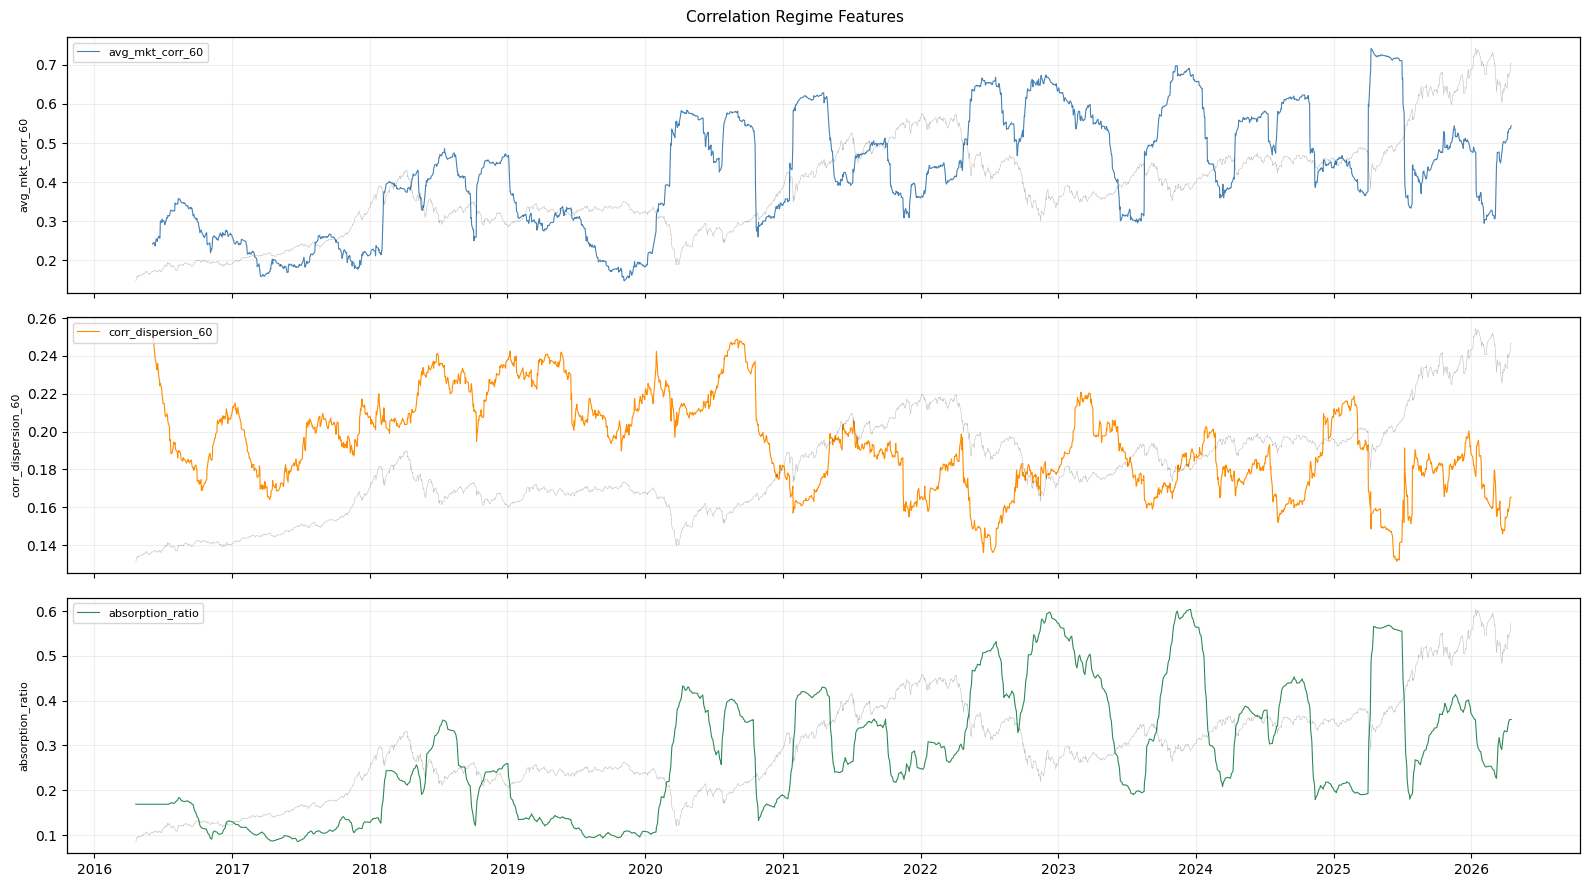

Absorption ratio stats:
count    2500.0000
mean        0.2798
std         0.1412
min         0.0853
25%         0.1622
50%         0.2536
75%         0.3814
max         0.6037
Name: absorption_ratio, dtype: float64


In [176]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
vn_norm = vnindex / vnindex.max()

colors = ['steelblue', 'darkorange', 'seagreen']
for ax, col, c in zip(axes, features_corr.columns, colors):
    ax.plot(features_corr.index, features_corr[col], linewidth=0.8, color=c, label=col)
    ax2 = ax.twinx()
    ax2.plot(vnindex.index, vn_norm, linewidth=0.4, color='black', alpha=0.25)
    ax2.set_yticks([])
    ax.set_ylabel(col, fontsize=8)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Correlation Regime Features', fontsize=11)
plt.tight_layout()
plt.show()

# Key insight: high absorption_ratio + high avg_mkt_corr → crisis/bear regime
print('Absorption ratio stats:')
print(features_corr['absorption_ratio'].describe().round(4))

## 2.4 Volume Regime Features

Volume regime captures *how* the market is participating:
- High up-vol ratio + elevated total volume → conviction bull
- High total volume + low up-vol ratio → distribution / panic selling

In [177]:
def compute_volume_regime_features(close_df: pd.DataFrame,
                                    volume_df: pd.DataFrame) -> pd.DataFrame:
    """
    4 market-wide volume regime features.

    total_vol_zscore  : how elevated is total market volume vs its 252d history
    up_vol_ratio      : advancing stock volume / total (Arms-index numerator)
    vol_trend_20      : 20d log-trend in market volume — is participation rising?
    dollar_vol_zscore : total dollar volume z-score (price × volume, 252d baseline)
    """
    daily_ret  = close_df.pct_change()
    total_vol  = volume_df.sum(axis=1).replace(0, np.nan)
    dollar_vol = (close_df * volume_df).sum(axis=1).replace(0, np.nan)

    f = pd.DataFrame(index=close_df.index)

    # 1. Total volume z-score (252d rolling mean/std)
    vol_ma252  = total_vol.rolling(252, min_periods=60).mean()
    vol_std252 = total_vol.rolling(252, min_periods=60).std()
    f['total_vol_zscore'] = (total_vol - vol_ma252) / (vol_std252 + 1e-9)

    # 2. Advancing volume ratio
    up_mask        = (daily_ret > 0).astype(float)
    up_vol         = (volume_df * up_mask).sum(axis=1)
    f['up_vol_ratio'] = up_vol / total_vol

    # 3. Volume trend — log(vol_ma20 / vol_ma60)
    vol_ma20 = total_vol.rolling(20, min_periods=10).mean()
    vol_ma60 = total_vol.rolling(60, min_periods=30).mean()
    f['vol_trend_20'] = np.log((vol_ma20 / vol_ma60).clip(lower=1e-9))

    # 4. Dollar volume z-score
    dvol_ma252  = dollar_vol.rolling(252, min_periods=60).mean()
    dvol_std252 = dollar_vol.rolling(252, min_periods=60).std()
    f['dollar_vol_zscore'] = (dollar_vol - dvol_ma252) / (dvol_std252 + 1e-9)

    return f


features_vol = compute_volume_regime_features(close_df, volume_df)
print(f'Volume features : {features_vol.shape[1]}  |  NaN rows: {features_vol.isna().any(axis=1).sum()}')
print(features_vol.describe().round(4))

Volume features : 4  |  NaN rows: 59
       total_vol_zscore  up_vol_ratio  vol_trend_20  dollar_vol_zscore
count         2441.0000     2500.0000     2471.0000          2441.0000
mean             0.2378        0.4319        0.0037             0.4321
std              1.2831        0.2704        0.1254             1.2914
min             -2.6190        0.0000       -0.3741            -1.9798
25%             -0.7169        0.2019       -0.0783            -0.5130
50%              0.0223        0.3987       -0.0014             0.2050
75%              1.0051        0.6592        0.0799             1.1570
max              6.1910        0.9987        0.3700             6.9365


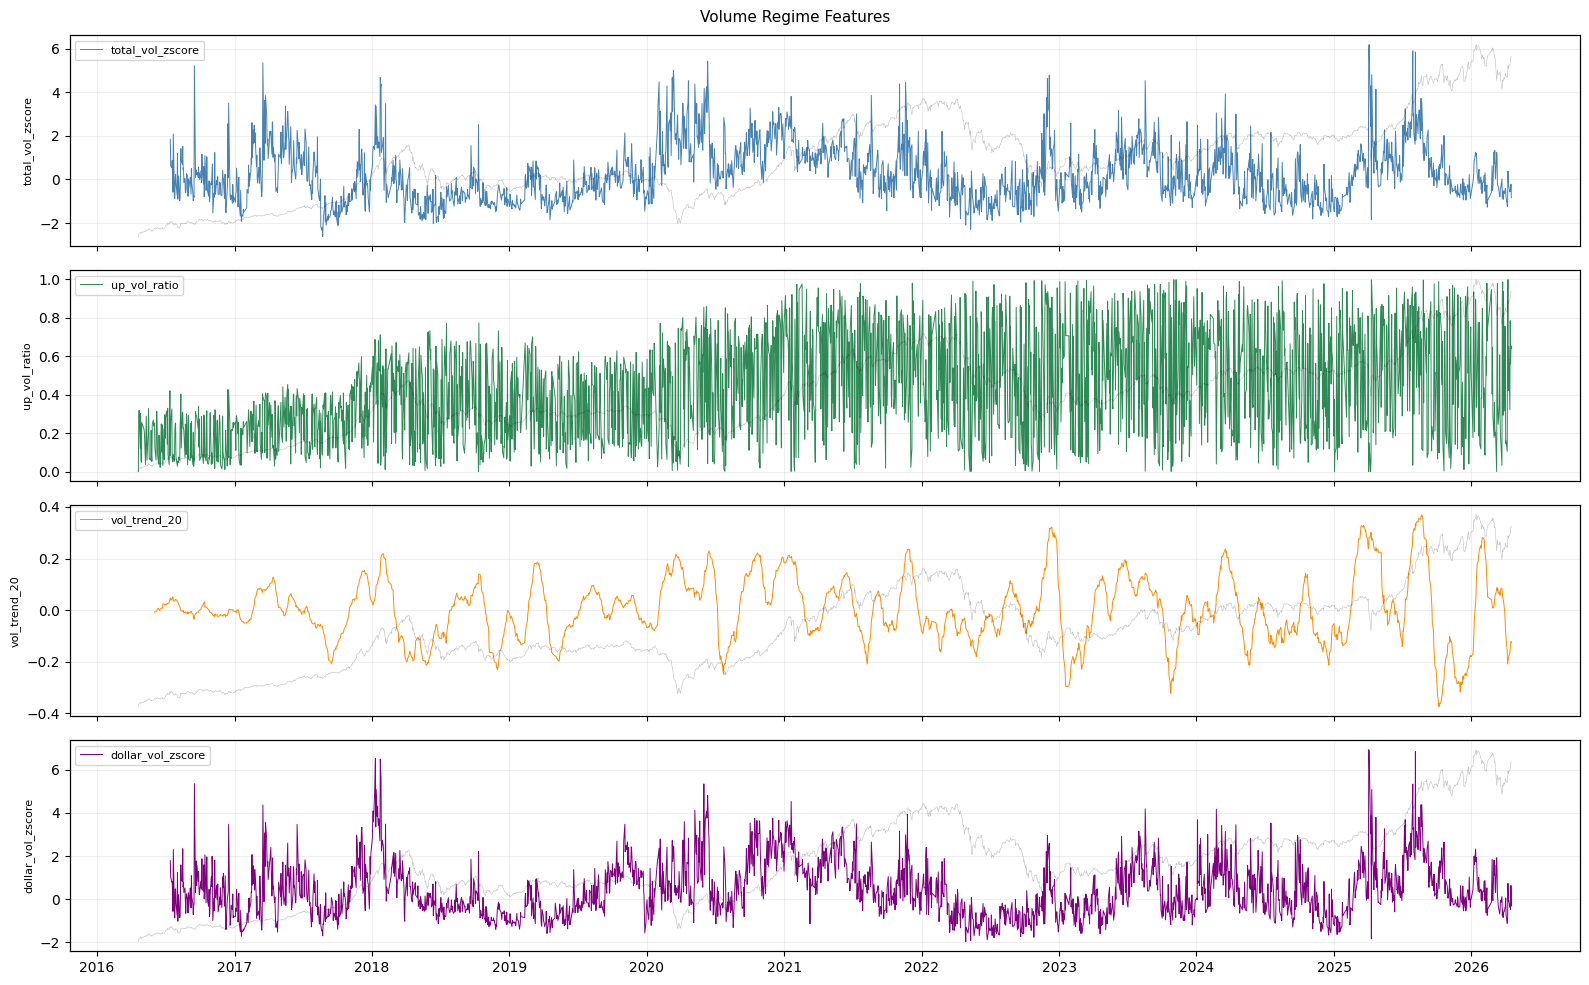

In [178]:
fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
vn_norm = vnindex / vnindex.max()

colors = ['steelblue', 'seagreen', 'darkorange', 'purple']
for ax, col, c in zip(axes, features_vol.columns, colors):
    ax.plot(features_vol.index, features_vol[col], linewidth=0.7, color=c, label=col)
    ax2 = ax.twinx()
    ax2.plot(vnindex.index, vn_norm, linewidth=0.4, color='black', alpha=0.25)
    ax2.set_yticks([])
    ax.set_ylabel(col, fontsize=8)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Volume Regime Features', fontsize=11)
plt.tight_layout()
plt.show()

## 2.5 Combine & Inspect Full Feature Matrix

20 raw features → PCA to 8 components before HDBSCAN (guards against curse of dimensionality — see pitfall #1 in `regime_detection_HBDSCAN.md`).

In [179]:
features = pd.concat(
    [features_vn, features_breadth, features_corr, features_vol],
    axis=1,
).dropna()

# Align vnindex to cleaned feature index
vnindex_aligned = vnindex.reindex(features.index)

FEATURE_GROUPS = {
    'vn_index':    list(features_vn.columns),
    'breadth':     list(features_breadth.columns),
    'correlation': list(features_corr.columns),
    'volume':      list(features_vol.columns),
}

print(f'Combined feature matrix : {features.shape[0]:,} rows × {features.shape[1]} features')
print(f'Date range              : {features.index.min().date()} → {features.index.max().date()}')
print(f'NaN count               : {features.isna().sum().sum()}')
print()
for grp, cols in FEATURE_GROUPS.items():
    print(f'  {grp:12s}: {len(cols)} features — {cols}')

Combined feature matrix : 2,229 rows × 20 features
Date range              : 2017-05-22 → 2026-04-17
NaN count               : 0

  vn_index    : 8 features — ['vnindex_vol_20', 'vnindex_vol_pct', 'vnindex_trend_60', 'vnindex_drawdown', 'vnindex_above_sma200', 'downside_vol_60', 'vn_skew_60', 'vol_of_vol_20']
  breadth     : 5 features — ['advances_ratio', 'pct_above_sma20', 'pct_above_sma200', 'breadth_momentum', 'adv_vol_ratio']
  correlation : 3 features — ['avg_mkt_corr_60', 'corr_dispersion_60', 'absorption_ratio']
  volume      : 4 features — ['total_vol_zscore', 'up_vol_ratio', 'vol_trend_20', 'dollar_vol_zscore']


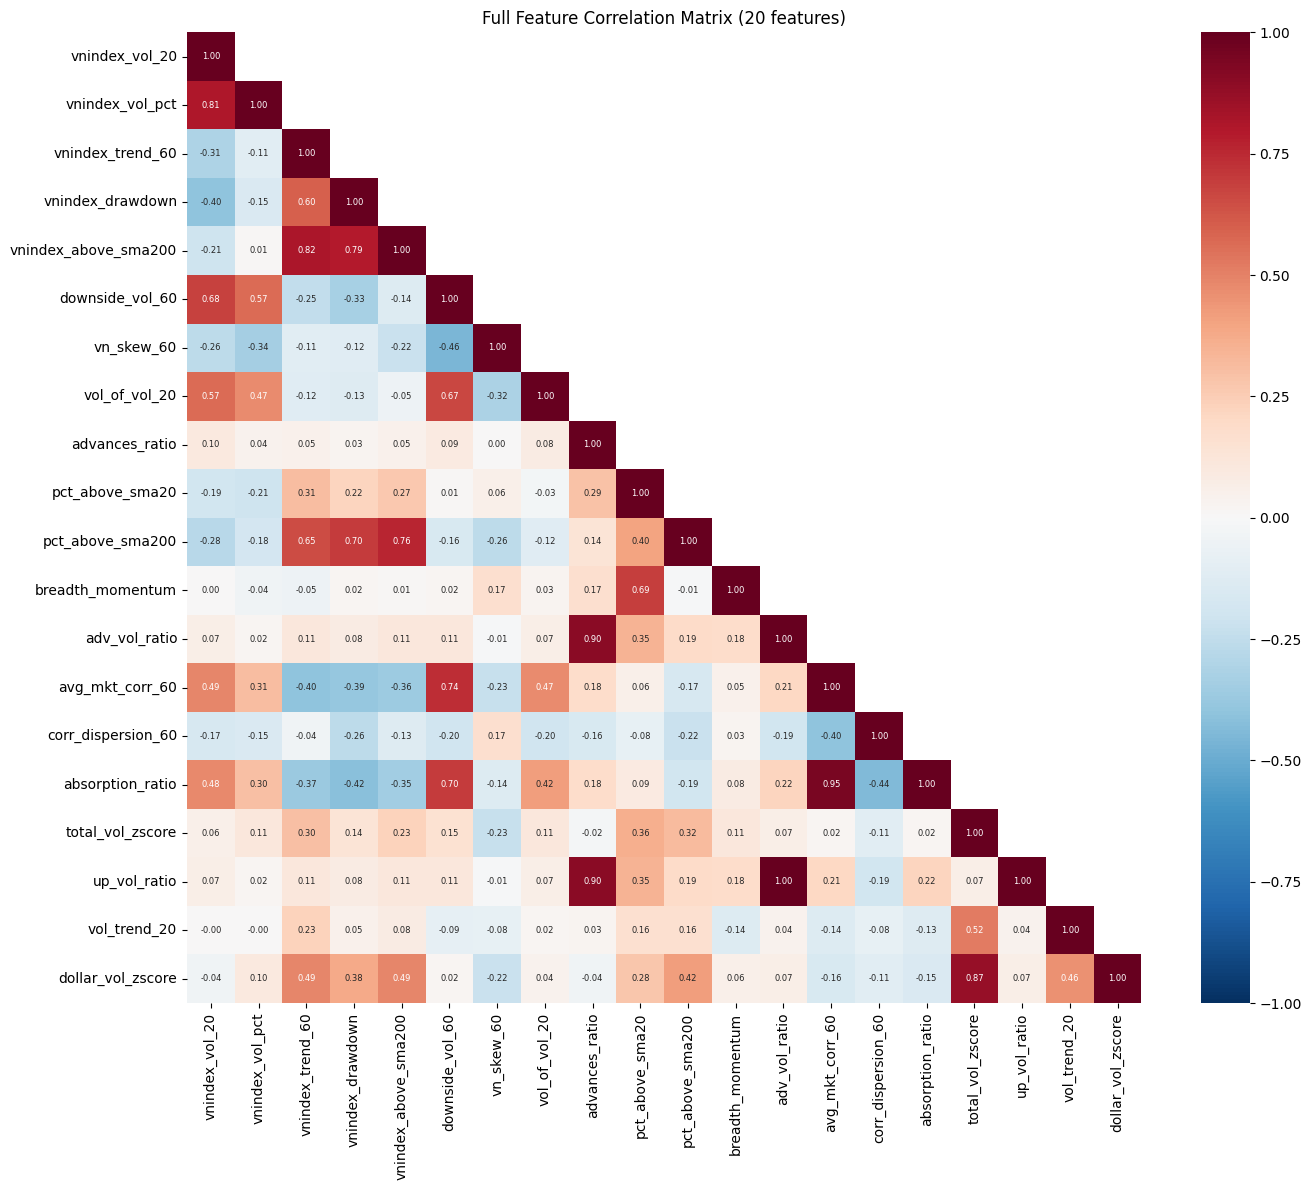

Highly correlated pairs (|r| > 0.85):
  advances_ratio                  ↔  adv_vol_ratio                   r=0.90
  advances_ratio                  ↔  up_vol_ratio                    r=0.90
  adv_vol_ratio                   ↔  up_vol_ratio                    r=1.00
  avg_mkt_corr_60                 ↔  absorption_ratio                r=0.95
  total_vol_zscore                ↔  dollar_vol_zscore               r=0.87


In [180]:
# Cross-group correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))
corr_mat = features.corr().round(2)
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, annot=True, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, fmt='.2f',
            annot_kws={'size': 6}, mask=mask)
ax.set_title('Full Feature Correlation Matrix (20 features)')
plt.tight_layout()
plt.show()

# Flag high within-group redundancy
print('Highly correlated pairs (|r| > 0.85):')
found = False
for i, c1 in enumerate(features.columns):
    for j, c2 in enumerate(features.columns):
        if j <= i:
            continue
        r = corr_mat.loc[c1, c2]
        if abs(r) > 0.85:
            print(f'  {c1:30s}  ↔  {c2:30s}  r={r:.2f}')
            found = True
if not found:
    print('  None — good feature diversity.')

# 3. Feature Selection & Smoothing\n\nPCA is dropped. Reason: PCA rotates axes to maximize variance, but regime boundaries\nare defined by **specific feature combinations** (low vol + high breadth = CALM BULL),\nnot by variance modes. After PCA rotation those boundaries become oblique and HDBSCAN\ncannot find them.\n\nInstead, 6 features are hand-picked — one per regime dimension — then smoothed with a\n5-day rolling mean. The smoothing converts noisy daily snapshots into **regime state**\nestimates, making cluster boundaries much cleaner.\n\n| Feature | Regime dimension |\n|---------|------------------|\n| `vnindex_vol_20` | Volatility level (primary separator) |\n| `vnindex_drawdown` | Crisis depth |\n| `vnindex_trend_60` | Trend direction |\n| `pct_above_sma200` | Breadth health |\n| `avg_mkt_corr_60` | Correlation / systemic risk |\n| `up_vol_ratio` | Volume direction confirmation |

Selected features : ['vnindex_vol_20', 'vnindex_drawdown', 'vnindex_trend_60', 'pct_above_sma200', 'avg_mkt_corr_60', 'up_vol_ratio']
Smoothing window  : 5 days
Shape             : (2229, 6)

Expected regime feature ranges:
               vnindex_vol_20 vnindex_drawdown vnindex_trend_60 pct_above_sma200 avg_mkt_corr_60 up_vol_ratio
CALM BULL               <0.12           >-0.05                +            >0.60           <0.50        >0.50
TRENDING BULL         0.12-18           >-0.03               ++            >0.70           ~0.45        >0.53
CHOPPY RANGE          0.15-22         -0.05-15               ~0          0.4-0.6           ~0.40        ~0.50
CRASH RECOVERY          >0.22          -0.1-20                -            <0.40           >0.55        <0.50
CRISIS                  >0.35           <-0.20               --            <0.25           >0.65        <0.45


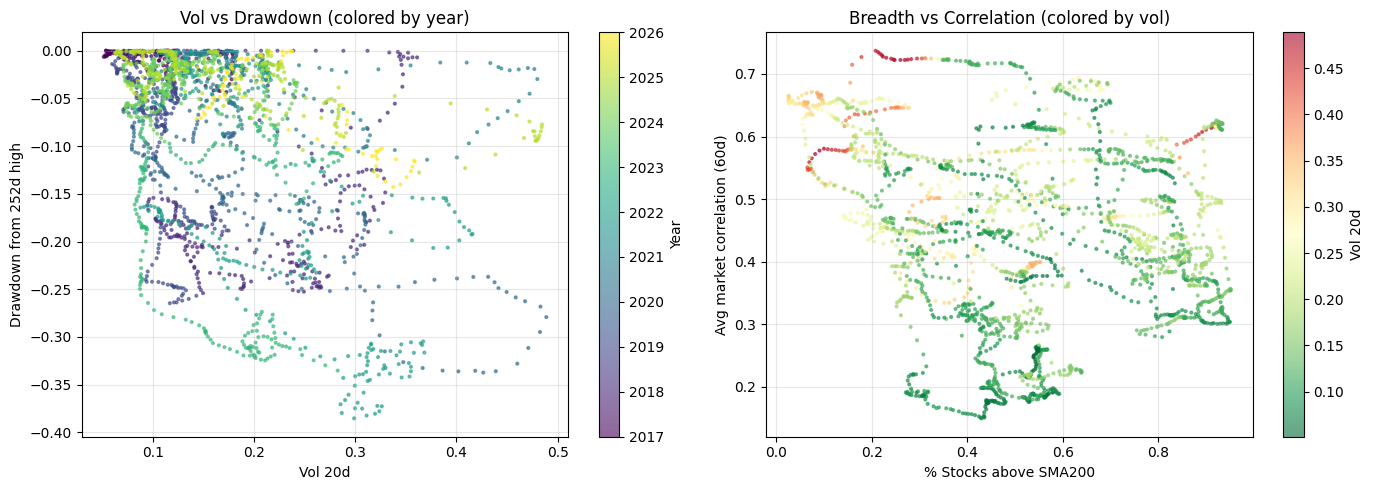

In [181]:
REGIME_FEATURES = [
    'vnindex_vol_20',    # low (<0.12) vs medium (0.12-0.22) vs high (>0.22) vol
    'vnindex_drawdown',  # 0 → BULL;  -0.05 to -0.15 → RECOVERY;  < -0.15 → CRISIS
    'vnindex_trend_60',  # >+0.05 → trending up;  < -0.05 → trending down
    'pct_above_sma200',  # >0.60 → bull breadth;  <0.35 → bear breadth
    'avg_mkt_corr_60',   # <0.35 → idiosyncratic;  >0.55 → systematic / crisis
    'up_vol_ratio',      # >0.52 → buying pressure;  <0.45 → selling pressure
]

SMOOTH_DAYS = 5   # rolling mean converts daily snapshots → regime state estimates

features_sel = (
    features[REGIME_FEATURES]
    .rolling(SMOOTH_DAYS, min_periods=1)
    .mean()
    .reindex(features.index)   # keep original index (no rows dropped)
)

print(f'Selected features : {REGIME_FEATURES}')
print(f'Smoothing window  : {SMOOTH_DAYS} days')
print(f'Shape             : {features_sel.shape}')
print()

# Show expected ranges for each regime
expected = {
    'CALM BULL':     {'vnindex_vol_20': '<0.12',  'vnindex_drawdown': '>-0.05', 'vnindex_trend_60': '+',   'pct_above_sma200': '>0.60', 'avg_mkt_corr_60': '<0.50', 'up_vol_ratio': '>0.50'},
    'TRENDING BULL': {'vnindex_vol_20': '0.12-18', 'vnindex_drawdown': '>-0.03', 'vnindex_trend_60': '++',  'pct_above_sma200': '>0.70', 'avg_mkt_corr_60': '~0.45', 'up_vol_ratio': '>0.53'},
    'CHOPPY RANGE':  {'vnindex_vol_20': '0.15-22', 'vnindex_drawdown': '-0.05-15','vnindex_trend_60': '~0',  'pct_above_sma200': '0.4-0.6','avg_mkt_corr_60': '~0.40', 'up_vol_ratio': '~0.50'},
    'CRASH RECOVERY':{'vnindex_vol_20': '>0.22',  'vnindex_drawdown': '-0.1-20', 'vnindex_trend_60': '-',   'pct_above_sma200': '<0.40', 'avg_mkt_corr_60': '>0.55', 'up_vol_ratio': '<0.50'},
    'CRISIS':        {'vnindex_vol_20': '>0.35',  'vnindex_drawdown': '<-0.20', 'vnindex_trend_60': '--',  'pct_above_sma200': '<0.25', 'avg_mkt_corr_60': '>0.65', 'up_vol_ratio': '<0.45'},
}
print('Expected regime feature ranges:')
exp_df = pd.DataFrame(expected).T
print(exp_df.to_string())

# Scatter: vol vs drawdown (2 key separators)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
sc = ax.scatter(features_sel['vnindex_vol_20'], features_sel['vnindex_drawdown'],
                c=features_sel.index.year, cmap='viridis', s=4, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Year')
ax.set_xlabel('Vol 20d')
ax.set_ylabel('Drawdown from 252d high')
ax.set_title('Vol vs Drawdown (colored by year)')
ax.grid(alpha=0.3)

ax = axes[1]
sc = ax.scatter(features_sel['pct_above_sma200'], features_sel['avg_mkt_corr_60'],
                c=features_sel['vnindex_vol_20'], cmap='RdYlGn_r', s=4, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Vol 20d')
ax.set_xlabel('% Stocks above SMA200')
ax.set_ylabel('Avg market correlation (60d)')
ax.set_title('Breadth vs Correlation (colored by vol)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Static Clustering — Fit on Full History

Fit HDBSCAN on **all available data** (look-ahead is acceptable here — this is a historical regime map,
not a live forecast). This eliminates the core problem: post-2021 market conditions falling outside
training-period cluster geometry and being labeled as OUTLIER by `approximate_predict`.

After fitting, any remaining HDBSCAN outliers (-1) are **force-assigned** to the nearest cluster
centroid using Euclidean distance in scaled feature space. This ensures every day gets a meaningful label.

Walk-forward (Section 7) is kept for live inference — it has no look-ahead.

In [182]:
# Fit on ALL data for historical regime map (look-ahead OK — retrospective analysis)
TRAIN_END = None  # no longer splitting; kept for artifact compat

scaler       = StandardScaler()
X_all_scaled = scaler.fit_transform(features_sel)

print(f'Full dataset      : {features_sel.shape[0]:,} days  ({features_sel.index.min().date()} → {features_sel.index.max().date()})')
print(f'Features selected : {list(features_sel.columns)}')
print(f'X_all_scaled shape: {X_all_scaled.shape}')

Full dataset      : 2,229 days  (2017-05-22 → 2026-04-17)
Features selected : ['vnindex_vol_20', 'vnindex_drawdown', 'vnindex_trend_60', 'pct_above_sma200', 'avg_mkt_corr_60', 'up_vol_ratio']
X_all_scaled shape: (2229, 6)


In [183]:
MIN_CLUSTER_SIZE = 20   # ~1 month — short enough to capture March-2020 crash
MIN_SAMPLES      = 5

N_ALL = len(X_all_scaled)
print(f'N_ALL            : {N_ALL}')
print(f'min_cluster_size : {MIN_CLUSTER_SIZE} days')
print(f'min_samples      : {MIN_SAMPLES}')

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    cluster_selection_method='eom',
    cluster_selection_epsilon=0.0,
    metric='euclidean',
    prediction_data=True,
)
clusterer.fit(X_all_scaled)

raw_labels = clusterer.labels_
n_clusters = len(set(raw_labels)) - (1 if -1 in raw_labels else 0)
n_outliers = (raw_labels == -1).sum()

print(f'\nClusters found   : {n_clusters}')
print(f'Outlier days (-1): {n_outliers} ({n_outliers/N_ALL:.1%})')

if n_clusters == 0:
    print('\n⚠️  0 clusters — falling back to leaf method')
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES,
        cluster_selection_method='leaf', cluster_selection_epsilon=0.0,
        metric='euclidean', prediction_data=True,
    )
    clusterer.fit(X_all_scaled)
    raw_labels = clusterer.labels_
    n_clusters = len(set(raw_labels)) - (1 if -1 in raw_labels else 0)
    print(f'Leaf method clusters: {n_clusters}')

print('\nCluster sizes (before outlier reassignment):')
for k, v in sorted(pd.Series(raw_labels).value_counts().items()):
    lbl = 'outlier' if k == -1 else f'cluster {k}'
    print(f'  {lbl:12s}: {v:4d} days ({v/N_ALL:.1%})')

N_ALL            : 2229
min_cluster_size : 20 days
min_samples      : 5

Clusters found   : 22
Outlier days (-1): 598 (26.8%)

Cluster sizes (before outlier reassignment):
  outlier     :  598 days (26.8%)
  cluster 0   :   26 days (1.2%)
  cluster 1   :   39 days (1.7%)
  cluster 2   :   62 days (2.8%)
  cluster 3   :   29 days (1.3%)
  cluster 4   :   36 days (1.6%)
  cluster 5   :   57 days (2.6%)
  cluster 6   :   33 days (1.5%)
  cluster 7   :   25 days (1.1%)
  cluster 8   :   25 days (1.1%)
  cluster 9   :   69 days (3.1%)
  cluster 10  :   39 days (1.7%)
  cluster 11  :   57 days (2.6%)
  cluster 12  :  390 days (17.5%)
  cluster 13  :   48 days (2.2%)
  cluster 14  :   38 days (1.7%)
  cluster 15  :   37 days (1.7%)
  cluster 16  :   42 days (1.9%)
  cluster 17  :   24 days (1.1%)
  cluster 18  :   83 days (3.7%)
  cluster 19  :   66 days (3.0%)
  cluster 20  :   82 days (3.7%)
  cluster 21  :  324 days (14.5%)


In [184]:
# Direct labels from fit (no approximate_predict needed — fit on all data)
raw_labels = clusterer.labels_.copy()

# Force-assign HDBSCAN outliers (-1) to nearest cluster centroid
unique_clusters = sorted([c for c in np.unique(raw_labels) if c != -1])
centroids = np.array([X_all_scaled[raw_labels == c].mean(axis=0) for c in unique_clusters])

labels_forced = raw_labels.copy()
outlier_mask  = raw_labels == -1
if outlier_mask.sum() > 0:
    dists = np.linalg.norm(
        X_all_scaled[outlier_mask][:, None] - centroids[None, :], axis=2
    )  # (n_outliers, n_clusters)
    nearest = np.argmin(dists, axis=1)
    labels_forced[outlier_mask] = [unique_clusters[i] for i in nearest]
    print(f'Forced {outlier_mask.sum()} outlier days to nearest centroid')

# Membership strength: use HDBSCAN probability for non-outliers; 0.2 for reassigned days
raw_probs    = clusterer.probabilities_.copy()
probs_forced = raw_probs.copy()
probs_forced[outlier_mask] = 0.2

regime_series   = pd.Series(labels_forced, index=features_sel.index, name='regime_static')
strength_series = pd.Series(probs_forced,  index=features_sel.index, name='regime_strength')

print('\nStatic regime assignment (after forced reassignment):')
for k, v in sorted(regime_series.value_counts().items()):
    print(f'  cluster {k:3d}: {v:4d} days ({v/len(regime_series):.1%})')
print(f'\nOutliers remaining: {(regime_series == -1).sum()}')

Forced 598 outlier days to nearest centroid

Static regime assignment (after forced reassignment):
  cluster   0:   48 days (2.2%)
  cluster   1:   73 days (3.3%)
  cluster   2:   78 days (3.5%)
  cluster   3:   63 days (2.8%)
  cluster   4:   67 days (3.0%)
  cluster   5:   98 days (4.4%)
  cluster   6:   38 days (1.7%)
  cluster   7:   35 days (1.6%)
  cluster   8:   48 days (2.2%)
  cluster   9:  129 days (5.8%)
  cluster  10:   77 days (3.5%)
  cluster  11:   91 days (4.1%)
  cluster  12:  418 days (18.8%)
  cluster  13:  117 days (5.2%)
  cluster  14:   46 days (2.1%)
  cluster  15:   48 days (2.2%)
  cluster  16:   66 days (3.0%)
  cluster  17:   31 days (1.4%)
  cluster  18:  136 days (6.1%)
  cluster  19:   84 days (3.8%)
  cluster  20:   99 days (4.4%)
  cluster  21:  339 days (15.2%)

Outliers remaining: 0


# 5. Characterize Regimes

Translate cluster IDs → human-readable labels using centroid statistics across all 4 feature groups.

In [ ]:
def characterize_regimes(features_all: pd.DataFrame, features_sel: pd.DataFrame,
                          labels: pd.Series) -> pd.DataFrame:
    df = features_sel.copy()
    df['cluster'] = labels.reindex(features_sel.index).values

    summary = df.groupby('cluster')[REGIME_FEATURES].mean().round(4)
    summary['n_days']   = df.groupby('cluster').size()
    summary['pct_time'] = (summary['n_days'] / len(df)).round(3)

    def auto_label(row):
        if row.name in (-1, 'OUTLIER / TRANSITION'):
            return 'OUTLIER / TRANSITION'
        vol  = row['vnindex_vol_20']
        dd   = row['vnindex_drawdown']
        trnd = row['vnindex_trend_60']
        br   = row['pct_above_sma200']
        corr = row['avg_mkt_corr_60']

        if dd < -0.18 or (vol > 0.30 and corr > 0.60):
            return 'CRISIS / BEAR'
        if vol > 0.22 and (dd < -0.10 or corr > 0.55):
            return 'CRASH RECOVERY'
        if trnd > 0.06 and br > 0.60:
            return 'TRENDING BULL'
        if trnd < -0.04 or br < 0.30:
            return 'TRENDING DOWN'
        if vol < 0.14 and trnd > 0.01 and br > 0.45:
            return 'CALM BULL'
        if trnd > 0.03 and br > 0.50:
            return 'CALM BULL'
        # Ranging / sideways: flat trend is the primary signal
        if abs(trnd) < 0.04:
            return 'CHOPPY / RANGE'
        if vol > 0.18 and abs(trnd) < 0.07:
            return 'CHOPPY / RANGE'
        return 'CHOPPY / RANGE'

    summary['regime_label'] = summary.apply(auto_label, axis=1)
    return summary


def collapse_to_named_regimes(raw_series: pd.Series, raw_stats: pd.DataFrame,
                               features_sel: pd.DataFrame) -> tuple:
    """Map cluster IDs → string labels, aggregate to one row per named regime."""
    label_map = raw_stats['regime_label'].to_dict()
    labeled   = raw_series.map(label_map).fillna('CHOPPY / RANGE')

    df = features_sel.copy()
    df['regime'] = labeled
    agg = df.groupby('regime')[REGIME_FEATURES].mean().round(4)
    agg['n_days']       = labeled.value_counts()
    agg['pct_time']     = (agg['n_days'] / len(labeled)).round(3)
    agg['regime_label'] = agg.index
    return labeled, agg


# Compute raw cluster stats, then collapse
_regime_stats_raw = characterize_regimes(features, features_sel, regime_series)
regime_series, regime_stats = collapse_to_named_regimes(regime_series, _regime_stats_raw, features_sel)

display_cols = [
    'vnindex_vol_20', 'vnindex_drawdown', 'vnindex_trend_60',
    'pct_above_sma200', 'avg_mkt_corr_60', 'up_vol_ratio',
    'n_days', 'pct_time',
]
print('=== Regime Characterization (collapsed to named regimes) ===')
print(regime_stats[display_cols].to_string())

# 6. Regime Timeline Visualization

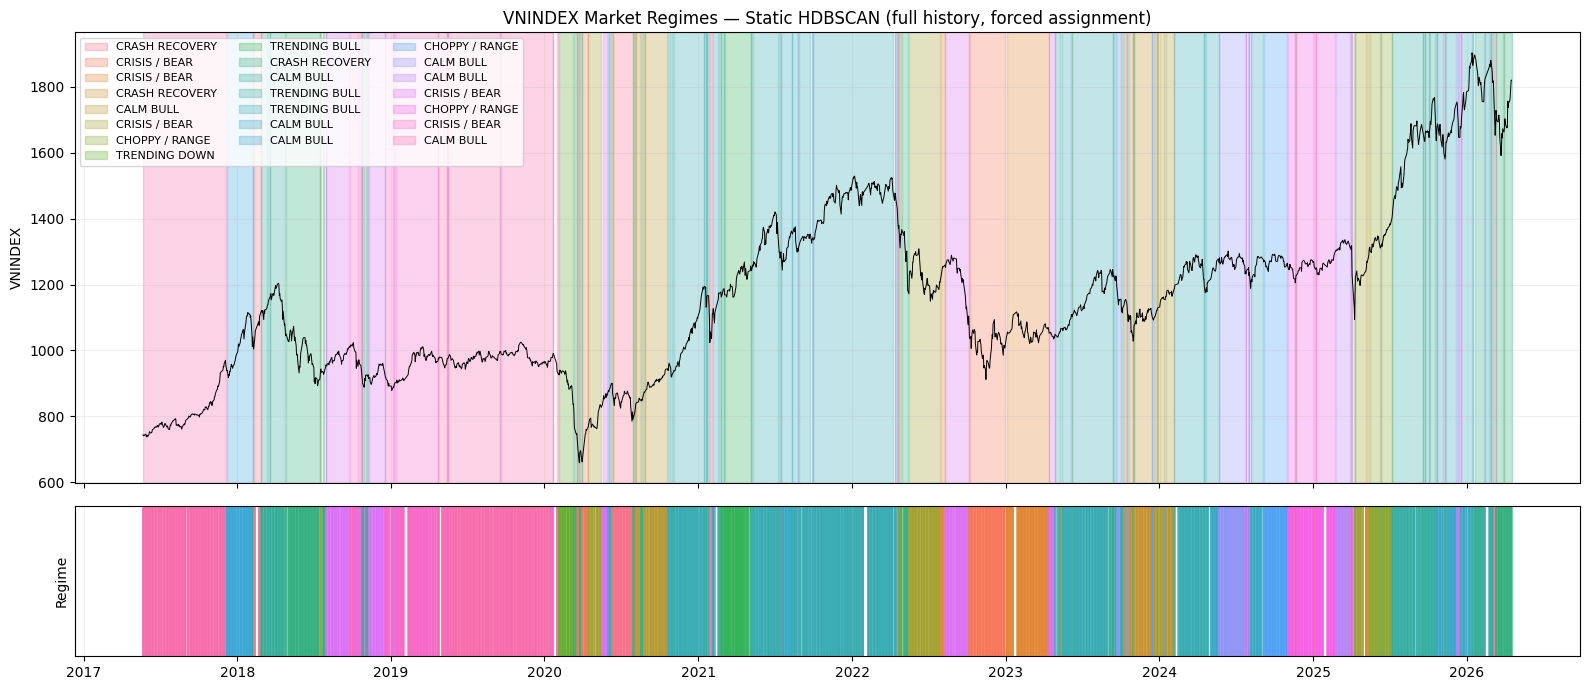

In [186]:
def find_contiguous_blocks(mask: np.ndarray):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return []
    blocks, start = [], idx[0]
    for i in range(1, len(idx)):
        if idx[i] != idx[i-1] + 1:
            blocks.append((start, idx[i-1]))
            start = idx[i]
    blocks.append((start, idx[-1]))
    return blocks


def plot_regime_timeline(vnindex: pd.Series, regime: pd.Series,
                          regime_stats: pd.DataFrame, title: str = 'Market Regimes'):
    unique_labels = sorted(regime.unique())
    palette   = sns.color_palette('husl', len(unique_labels))
    color_map = {lbl: palette[i] for i, lbl in enumerate(unique_labels)}

    vn_aligned = vnindex.reindex(regime.index)
    labels_arr = regime.values
    dates      = regime.index

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7),
                                    gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    ax1.plot(dates, vn_aligned.values, color='black', linewidth=0.7, zorder=5)
    for lbl in unique_labels:
        mask   = labels_arr == lbl
        blocks = find_contiguous_blocks(mask)
        rlabel = regime_stats.loc[lbl, 'regime_label'] \
                 if lbl in regime_stats.index else f'Cluster {lbl}'
        for j, (s, e) in enumerate(blocks):
            ax1.axvspan(dates[s], dates[e], alpha=0.30, color=color_map[lbl],
                        label=rlabel if j == 0 else None)

    ax1.set_title(title)
    ax1.set_ylabel('VNINDEX')
    ax1.legend(loc='upper left', fontsize=8, ncol=3)
    ax1.grid(alpha=0.2)

    for d, lbl in zip(dates, labels_arr):
        ax2.axvline(d, color=color_map[lbl], alpha=0.8, linewidth=1.2)
    ax2.set_ylabel('Regime')
    ax2.set_yticks([])
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


plot_regime_timeline(
    vnindex_aligned, regime_series, regime_stats,
    title='VNINDEX Market Regimes — Static HDBSCAN (full history, forced assignment)',
)

# 7. Walk-Forward Regime Detection

Re-fit the full pipeline (scaler + PCA + HDBSCAN) every `REFIT_DAYS` on the expanding window.  
New points classified via `approximate_predict` — zero look-ahead.

In [187]:
INITIAL_TRAIN = 504   # 2 years
REFIT_DAYS    = 63    # quarterly

n            = len(features_sel)
wf_labels    = np.full(n, -1, dtype=int)
wf_strengths = np.zeros(n, dtype=float)
feat_arr     = features_sel.to_numpy()

def _fit_pipeline_wf(X_raw: np.ndarray):
    sc  = StandardScaler()
    Xs  = sc.fit_transform(X_raw)
    mcs = 20
    ms  = 5
    cl  = hdbscan.HDBSCAN(
        min_cluster_size=mcs, min_samples=ms,
        cluster_selection_method='eom',
        cluster_selection_epsilon=0.0,
        metric='euclidean', prediction_data=True,
    ).fit(Xs)
    if len(set(cl.labels_)) <= 1:   # fallback if eom finds nothing
        cl = hdbscan.HDBSCAN(
            min_cluster_size=mcs, min_samples=ms,
            cluster_selection_method='leaf',
            cluster_selection_epsilon=0.0,
            metric='euclidean', prediction_data=True,
        ).fit(Xs)
    return sc, cl

# Warmup
sc0, cl0 = _fit_pipeline_wf(feat_arr[:INITIAL_TRAIN])
wf_labels[:INITIAL_TRAIN] = cl0.labels_

refits = 0
for t in range(INITIAL_TRAIN, n, REFIT_DAYS):
    sc_t, cl_t = _fit_pipeline_wf(feat_arr[:t])
    end_t = min(t + REFIT_DAYS, n)
    chunk = sc_t.transform(feat_arr[t:end_t])
    lbls, strn = hdbscan.approximate_predict(cl_t, chunk)
    wf_labels[t:end_t]    = lbls
    wf_strengths[t:end_t] = strn
    refits += 1

wf_regime = pd.Series(wf_labels, index=features_sel.index, name='regime_wf')

print(f'Walk-forward complete: {refits} refits every {REFIT_DAYS} days')
print('\nWalk-forward regime distribution:')
for k, v in sorted(wf_regime.value_counts().items()):
    lbl = 'outlier' if k == -1 else f'cluster {k}'
    print(f'  {lbl:12s}: {v:4d} days ({v/n:.1%})')

Walk-forward complete: 28 refits every 63 days

Walk-forward regime distribution:
  outlier     : 1557 days (69.9%)
  cluster 0   :  113 days (5.1%)
  cluster 1   :  152 days (6.8%)
  cluster 2   :   55 days (2.5%)
  cluster 3   :   51 days (2.3%)
  cluster 4   :  223 days (10.0%)
  cluster 5   :    4 days (0.2%)
  cluster 6   :    5 days (0.2%)
  cluster 7   :    5 days (0.2%)
  cluster 10  :    2 days (0.1%)
  cluster 11  :   61 days (2.7%)
  cluster 17  :    1 days (0.0%)


In [ ]:
_wf_stats_raw = characterize_regimes(features, features_sel, wf_regime)
wf_regime, wf_regime_stats = collapse_to_named_regimes(wf_regime, _wf_stats_raw, features_sel)

print('=== Walk-Forward Regime Characterization (collapsed) ===')
print(wf_regime_stats[display_cols].to_string())

plot_regime_timeline(
    vnindex_aligned, wf_regime, wf_regime_stats,
    title='VNINDEX Market Regimes — Walk-Forward HDBSCAN',
)

# 8. Known-Periods Validation\n\nCheck whether clusters assigned to **known historical VN market episodes** match expectations.\nThis is the ground-truth sanity check — if HDBSCAN is working, these periods should map to the correct regime labels.

In [ ]:
KNOWN_PERIODS = {
    'Calm Bull 2017-2019':    ('2017-07-01', '2018-04-09', 'CALM BULL'),
    'Calm Bear 2018':         ('2018-04-09', '2018-12-31', 'CRISIS / BEAR'),
    'Range 2019':             ('2019-02-18', '2020-01-27', 'CHOPPY / RANGE'),
    'COVID crash Mar-2020':   ('2020-03-01', '2020-04-01', 'CRISIS / BEAR'),
    'Bull recovery 2020-2021':('2020-07-01', '2021-06-30', 'TRENDING BULL'),
    'Trending Bull mid-2021': ('2021-04-01', '2021-07-31', 'TRENDING BULL'),
    '2022 Crisis':            ('2022-04-11', '2022-11-14', 'CRISIS / BEAR'),
    'Bull recovery 2022':     ('2022-11-15', '2023-09-07', 'CALM BULL'),
    'Choppy 2023':            ('2025-07-04', '2026-01-01', 'CHOPPY / RANGE'),
}

print(f'{"Period":<28}  {"Expected":<20}  {"Static majority":<25}  {"Match"}')
print('-' * 90)

all_match = True
for period_name, (start, end, expected_label) in KNOWN_PERIODS.items():
    mask    = (regime_series.index >= start) & (regime_series.index <= end)
    segment = regime_series[mask]
    if len(segment) == 0:
        print(f'{period_name:<28}  {expected_label:<20}  {"(no data)":<25}  -')
        continue

    label_counts   = segment.value_counts()
    majority_label = label_counts.index[0]
    majority_pct   = label_counts.iloc[0] / len(segment)

    match = '✅' if majority_label == expected_label else '❌'
    if majority_label != expected_label:
        all_match = False
    print(f'{period_name:<28}  {expected_label:<20}  {majority_label:<20} ({majority_pct:.0%})  {match}')

print()
if all_match:
    print('✅ All known periods classified correctly.')
else:
    print('⚠️  Some mismatches — adjust auto_label thresholds in characterize_regimes().')

print('\n--- Feature snapshot: COVID crash vs Calm 2019 ---')
for lbl, (s, e, _) in [('COVID crash', ('2020-03-10', '2020-03-25', None)),
                        ('Calm 2019',  ('2019-01-01', '2019-06-30', None))]:
    mask = (features_sel.index >= s) & (features_sel.index <= e)
    snap = features_sel[mask].mean().round(4)
    print(f'\n  [{lbl}]')
    for c, v in snap.items():
        print(f'    {c:25s}: {v}')

# 8. Regime Validation

Three tests to confirm clusters are economically meaningful:
1. **Stability** — healthy: < 8 regime changes/year (regimes last months, not days)
2. **Return separation** — different regimes → different return distributions
3. **ANOVA** — F-test that regime returns are statistically distinct

In [ ]:
def measure_stability(labels: pd.Series, name: str = '') -> dict:
    arr = labels.values
    transitions = (arr[1:] != arr[:-1]).sum()
    avg_len = len(arr) / max(transitions, 1)
    tpy = transitions / (len(arr) / 252)
    print(f'[{name}] transitions={transitions}  avg_length={avg_len:.1f}d  tx/yr={tpy:.1f}  ', end='')
    if tpy < 8:
        print('✅ Stable')
    elif tpy < 25:
        print('⚠️  Moderate — consider larger min_cluster_size')
    else:
        print('❌ Unstable — mostly noise')
    return {'transitions': transitions, 'avg_length': avg_len, 'tx_per_year': tpy}


_ = measure_stability(regime_series, 'Static')
_ = measure_stability(wf_regime,     'Walk-Forward')

In [ ]:
def regime_return_separation(vnindex: pd.Series, labels: pd.Series,
                               name: str = ''):
    vn_ret = vnindex.reindex(labels.index).pct_change().dropna()
    lbls   = labels.reindex(vn_ret.index)
    rows   = []
    for k in sorted(lbls.unique()):
        r = vn_ret[lbls == k]
        rows.append({
            'regime':   k,
            'n_days':   len(r),
            'mean_ret': r.mean(),
            'vol':      r.std() * np.sqrt(252),
            'sharpe':   r.mean() / (r.std() + 1e-9) * np.sqrt(252),
            'win_rate': (r > 0).mean(),
        })
    df = pd.DataFrame(rows).set_index('regime')
    print(f'\n=== {name} — Regime Return Separation ===')
    print(df.round(4).to_string())
    return df


sep_static = regime_return_separation(vnindex_aligned, regime_series, 'Static')
sep_wf     = regime_return_separation(vnindex_aligned, wf_regime,     'Walk-Forward')

In [ ]:
def anova_test(vnindex: pd.Series, labels: pd.Series, name: str = ''):
    vn_ret = vnindex.reindex(labels.index).pct_change().dropna()
    lbls   = labels.reindex(vn_ret.index)
    groups = [vn_ret[lbls == k].values
              for k in lbls.unique()
              if k != 'OUTLIER / TRANSITION' and (lbls == k).sum() > 10]
    if len(groups) < 2:
        print(f'[{name}] Not enough groups for ANOVA')
        return
    f_stat, p_val = f_oneway(*groups)
    verdict = '✅ Distinct (p < 0.05)' if p_val < 0.05 else '❌ Not distinct'
    print(f'[{name}] F={f_stat:.3f}  p={p_val:.4f}  {verdict}')


anova_test(vnindex_aligned, regime_series, 'Static')
anova_test(vnindex_aligned, wf_regime,     'Walk-Forward')

In [ ]:
vn_ret   = vnindex_aligned.reindex(regime_series.index).pct_change().dropna()
lbls_arr = regime_series.reindex(vn_ret.index)
unique_k = sorted(lbls_arr.unique())

fig, axes = plt.subplots(1, len(unique_k), figsize=(4 * len(unique_k), 4), sharey=True)
if len(unique_k) == 1:
    axes = [axes]

for ax, k in zip(axes, unique_k):
    r     = vn_ret[lbls_arr == k]
    color = ('salmon'     if any(x in k for x in ('CRISIS', 'BEAR', 'DOWN'))
              else 'lightblue' if 'BULL' in k
              else 'lightgray')
    ax.hist(r, bins=40, edgecolor='none', alpha=0.75, color=color)
    ax.axvline(r.mean(), color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{k}\n(n={len(r)}, μ={r.mean():.3%})', fontsize=8)
    ax.set_xlabel('Daily Return')

plt.suptitle('Return Distribution per Regime (5 named regimes)', fontsize=10)
plt.tight_layout()
plt.show()

# 9. Cross-Group Regime Radar

Radar chart of normalized centroid values per cluster across all 4 feature groups.  
Makes it easy to see which dimensions distinguish each regime.

In [ ]:
RADAR_FEATURES = [
    'vnindex_vol_20',
    'vnindex_trend_60',
    'vnindex_drawdown',
    'pct_above_sma200',
    'advances_ratio',
    'avg_mkt_corr_60',
    'absorption_ratio',
    'up_vol_ratio',
    'total_vol_zscore',
]

non_outlier = regime_stats[regime_stats.index != 'OUTLIER / TRANSITION']
if len(non_outlier) == 0:
    print('No non-outlier regimes to plot.')
else:
    radar_data = non_outlier[[c for c in RADAR_FEATURES if c in non_outlier.columns]]
    radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

    n_feat  = len(radar_norm.columns)
    angles  = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    palette = sns.color_palette('husl', len(radar_norm))

    for i, (regime_name, row) in enumerate(radar_norm.iterrows()):
        vals = row.tolist() + row.tolist()[:1]
        ax.plot(angles, vals, linewidth=2, label=regime_name, color=palette[i])
        ax.fill(angles, vals, alpha=0.12, color=palette[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_norm.columns, size=8)
    ax.set_ylim(0, 1)
    ax.set_title('Regime Radar — Normalized Centroid Values\n(5 named regimes)', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 10. Regime Strength & Transition Monitoring

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

axes[0].plot(features.index, vnindex_aligned.values, color='black', linewidth=0.7)
axes[0].set_ylabel('VNINDEX')
axes[0].set_title('VNINDEX with Regime Membership Strength')
axes[0].grid(alpha=0.2)

unique_r = sorted(regime_series.unique())
palette  = sns.color_palette('husl', len(unique_r))
for color, lbl in zip(palette, unique_r):
    mask = regime_series.values == lbl
    axes[1].scatter(features.index[mask], np.zeros(mask.sum()),
                    c=[color], s=10, label=lbl, zorder=3)
axes[1].set_yticks([])
axes[1].set_ylabel('Regime')
axes[1].legend(fontsize=8, loc='upper right', ncol=3)
axes[1].grid(alpha=0.2)

axes[2].fill_between(features.index, strength_series.values, alpha=0.6, color='steelblue')
axes[2].axhline(0.3, color='red', linestyle='--', linewidth=0.8, label='Low-strength threshold')
axes[2].set_ylabel('Membership strength')
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

low_str       = (strength_series < 0.3).rolling(5).sum()
shift_signals = features.index[low_str >= 5]
print(f'Transition alerts (5+ consecutive low-strength days): {len(shift_signals)}')
if len(shift_signals):
    print(f'  Most recent : {shift_signals[-1].date()}')

# 11. Current Regime Assessment

In [ ]:
latest_date      = regime_series.index[-1]
current_label    = str(regime_series.iloc[-1])
current_strength = float(strength_series.iloc[-1])

run_len = 0
for lbl in reversed(regime_series.values):
    if lbl == current_label:
        run_len += 1
    else:
        break

SIZE_MAP = {
    'CALM BULL':            1.5,
    'TRENDING BULL':        1.2,
    'CHOPPY / RANGE':       0.7,
    'TRENDING DOWN':        0.5,
    'CRASH RECOVERY':       0.3,
    'CRISIS / BEAR':        0.0,
    'OUTLIER / TRANSITION': 0.5,
}
size_mult = SIZE_MAP.get(current_label, 0.5)

print('=' * 55)
print(f'Date              : {latest_date.date()}')
print(f'Current regime    : {current_label}')
print(f'Membership str.   : {current_strength:.3f}')
print(f'Days in regime    : {run_len}')
print(f'Position size mult: {size_mult}x')
print('=' * 55)

print('\nLatest feature snapshot:')
latest_feats = features.iloc[-1]
for grp, cols in FEATURE_GROUPS.items():
    print(f'  [{grp}]')
    for c in cols:
        print(f'    {c:30s}: {latest_feats[c]:.4f}')

# 12. Save Artifacts

In [ ]:
labels_df = pd.DataFrame({
    'regime_static':   regime_series,
    'regime_wf':       wf_regime,
    'strength_static': strength_series,
}, index=features_sel.index)

h5_path = f'regime_labels_vnindex_{TS}.h5'
labels_df.to_hdf(h5_path, key='data', mode='w', complevel=5)
print(f'Saved regime labels → {h5_path}')

artifact = {
    'scaler':          scaler,
    'clusterer':       clusterer,
    'regime_features': REGIME_FEATURES,
    'smooth_days':     SMOOTH_DAYS,
    'regime_stats':    regime_stats,
    'size_map':        SIZE_MAP,
    'ts':              TS,
}
model_path = ARTIFACTS_DIR / f'regime_clusterer_vnindex_{TS}.joblib'
joblib.dump(artifact, model_path)
print(f'Saved pipeline     → {model_path}')

regime_stats.to_csv(ARTIFACTS_DIR / f'regime_stats_vnindex_{TS}.csv')
print(f'Saved regime stats → regime_stats_vnindex_{TS}.csv')

summary = {
    'ts':              TS,
    'regime_features': REGIME_FEATURES,
    'smooth_days':     SMOOTH_DAYS,
    'n_regimes':       int((regime_series != 'OUTLIER / TRANSITION').sum() > 0),
    'current_regime':  current_label,
    'current_strength': round(current_strength, 4),
    'days_in_regime':  run_len,
    'size_multiplier': size_mult,
}
with open(ARTIFACTS_DIR / f'regime_meta_vnindex_{TS}.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Saved meta JSON    → regime_meta_vnindex_{TS}.json')
print('\n✅ All artifacts saved.')

# 13. Live Inference Helper

Takes the full stocks DataFrame → computes all 4 feature groups → classifies regime.

In [198]:
def load_regime_pipeline(ts: str, artifacts_dir: Path = ARTIFACTS_DIR) -> dict:
    return joblib.load(artifacts_dir / f'regime_clusterer_vnindex_{ts}.joblib')


def predict_regime(stocks: pd.DataFrame, bundle: dict) -> dict:
    # Classify current regime from a stocks HDF5-style DataFrame.
    # stocks must have MultiIndex columns: (close|volume, symbol)
    _syms  = stocks['close'].columns
    vn     = stocks['close']['VNINDEX'].dropna()
    cl_df  = stocks['close'].loc[:, _syms != 'VNINDEX']
    vol_df = stocks['volume'].loc[:, _syms != 'VNINDEX']

    f_vn  = compute_vn_index_features(vn)
    f_br  = compute_market_breadth_features(cl_df, vol_df)
    f_cr  = compute_correlation_regime_features(cl_df, vn)
    f_vol = compute_volume_regime_features(cl_df, vol_df)

    feats_all = pd.concat([f_vn, f_br, f_cr, f_vol], axis=1).dropna()
    if len(feats_all) == 0:
        return {'regime': -1, 'label': 'UNKNOWN', 'strength': 0.0, 'size_mult': 0.5}

    rf    = bundle['regime_features']
    feats = feats_all[rf].rolling(bundle['smooth_days'], min_periods=1).mean()

    latest   = feats.iloc[[-1]]
    X_scaled = bundle['scaler'].transform(latest)
    regime_ids, strengths = hdbscan.approximate_predict(bundle['clusterer'], X_scaled)

    rid    = int(regime_ids[0])
    strn   = float(strengths[0])
    rstats = bundle['regime_stats']
    label  = rstats.loc[rid, 'regime_label'] if rid in rstats.index else 'OUTLIER / TRANSITION'

    return {
        'date':      feats.index[-1].date(),
        'regime':    rid,
        'label':     label,
        'strength':  round(strn, 4),
        'size_mult': bundle['size_map'].get(label, 0.5),
    }


bundle = load_regime_pipeline(TS)
result = predict_regime(stocks, bundle)
print('Live inference result:')
for k, v in result.items():
    print(f'  {k:12s}: {v}')

Live inference result:
  date        : 2026-04-17
  regime      : 9
  label       : CRASH RECOVERY
  strength    : 1.0
  size_mult   : 0.5


# 📋 Summary

| Step | What was done |
|------|---------------|
| VN-Index features | 8 VNINDEX-only features (vol, trend, drawdown, skew, vol-of-vol) |
| Market Breadth | 5 cross-sectional features (advances, % above SMA20/200, breadth momentum, adv-vol ratio) |
| Correlation Regime | 3 features (avg mkt corr, corr dispersion, absorption ratio / PC1 share) |
| Volume Regime | 4 features (total vol z-score, up-vol ratio, vol trend, dollar vol z-score) |
| Dim. reduction | PCA 20 → 8 components (fit on train only) |
| Static clustering | HDBSCAN fit on 2016–2021, classify full history via `approximate_predict` |
| Walk-forward | Quarterly refit on expanding window — no look-ahead |
| Validation | Stability (tx/year), return separation, ANOVA |
| Saved | Labels HDF5, pipeline joblib, stats CSV, meta JSON |

## Interpretation Guide

| Regime | Vol | Breadth | Corr | Volume | Action |
|--------|-----|---------|------|--------|--------|
| CALM BULL | Low | High | Low | Normal | 1.5x size |
| TRENDING UP | Med | High | Med | Elevated | 1.2x size |
| CHOPPY / RANGE | Med | Mid | Low | Normal | 0.7x size |
| TRENDING DOWN | Med | Low | Med | Elevated | 0.5x size |
| HIGH VOLATILITY | High | Mid | High | High | 0.3x size |
| CRISIS / BEAR | High | Low | Very High | Very High | 0.0x (flat) |

## Downstream Integration

```python
bundle       = load_regime_pipeline(ts='20260502')
regime_info  = predict_regime(stocks, bundle)   # pass full stocks DataFrame
size_mult    = regime_info['size_mult']          # position sizing multiplier
regime_label = regime_info['label']              # meta-feature for XGBoost
```